In [1]:
import pandas as pd 
import numpy as np


In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix , plot_confusion_matrix
from sklearn.preprocessing import StandardScaler

In [3]:
df=pd.read_csv('titanic.csv') #read csv

In [4]:
df #共有887筆觀察值，和7個變數 船艙等級 性別 同儕配偶是否在船上 小孩親人是否在船上 fare 倖存與否

,Pclass,Sex,Age,SiblingsSpouses_Aboard,ParentsChildren_Aboard,Fare,Survived
0,3,male,22.0,1,0,7.2500,0
1,1,female,38.0,1,0,71.2833,1
2,3,female,26.0,0,0,7.9250,1
3,1,female,35.0,1,0,53.1000,1
4,3,male,35.0,0,0,8.0500,0
...,...,...,...,...,...,...,...
882,2,male,27.0,0,0,13.0000,0
883,1,female,19.0,0,0,30.0000,1
884,3,female,7.0,1,2,23.4500,0
885,1,male,26.0,0,0,30.0000,1


In [5]:
df=pd.get_dummies(df, prefix=['col2']) #性別欄位需要創立虛擬變數
df

,Pclass,Age,SiblingsSpouses_Aboard,ParentsChildren_Aboard,Fare,Survived,col2_female,col2_male
0,3,22.0,1,0,7.2500,0,0,1
1,1,38.0,1,0,71.2833,1,1,0
2,3,26.0,0,0,7.9250,1,1,0
3,1,35.0,1,0,53.1000,1,1,0
4,3,35.0,0,0,8.0500,0,0,1
...,...,...,...,...,...,...,...,...
882,2,27.0,0,0,13.0000,0,0,1
883,1,19.0,0,0,30.0000,1,1,0
884,3,7.0,1,2,23.4500,0,1,0
885,1,26.0,0,0,30.0000,1,0,1


In [6]:
df2=pd.get_dummies(df['Pclass']) #船傖也需要創立虛擬變數

In [7]:
df2

,1,2,3
0,0,0,1
1,1,0,0
2,0,0,1
3,1,0,0
4,0,0,1
...,...,...,...
882,0,1,0
883,1,0,0
884,0,0,1
885,1,0,0


In [8]:
X=df[['Age','SiblingsSpouses_Aboard','ParentsChildren_Aboard','Fare']] #先將數值型資料丟入Ｘ，進行標準化動作

In [9]:
X=np.array(X) #轉np

In [10]:
X.shape

(887, 4)

In [11]:
X=StandardScaler().fit(X).transform(X) #將數值型資料進行標準化

In [12]:
X

array([[-0.52936601,  0.42990395, -0.4749808 , -0.50358635],
       [ 0.60426454,  0.42990395, -0.4749808 ,  0.78341245],
       [-0.24595837, -0.47585568, -0.4749808 , -0.49001959],
       ...,
       [-1.59214465,  0.42990395,  2.00330136, -0.17798419],
       [-0.24595837, -0.47585568, -0.4749808 , -0.04633641],
       [ 0.17915309, -0.47585568, -0.4749808 , -0.4935369 ]])

In [13]:
df3 = pd.DataFrame(X) #將array轉回pd

In [14]:
df3['D_Sex']=df['col2_female'] #pd將虛擬變數加回，dummies不能標準化，所以之後再加回

In [15]:
df3['Pclass1']=df2[1]

In [16]:
df3['Pclass2']=df2[2]

In [17]:
df3 # 0 1 2 3 分別為標準化後的 Age	SiblingsSpouses_Aboard	ParentsChildren_Aboard	Fare ，再加上虛擬變數

,0,1,2,3,D_Sex,Pclass1,Pclass2
0,-0.529366,0.429904,-0.474981,-0.503586,0,0,0
1,0.604265,0.429904,-0.474981,0.783412,1,1,0
2,-0.245958,-0.475856,-0.474981,-0.490020,1,0,0
3,0.391709,0.429904,-0.474981,0.417948,1,1,0
4,0.391709,-0.475856,-0.474981,-0.487507,0,0,0
...,...,...,...,...,...,...,...
882,-0.175106,-0.475856,-0.474981,-0.388018,0,0,1
883,-0.741922,-0.475856,-0.474981,-0.046336,1,1,0
884,-1.592145,0.429904,2.003301,-0.177984,1,0,0
885,-0.245958,-0.475856,-0.474981,-0.046336,0,1,0


In [18]:
X=np.array(df3)

In [19]:
X.shape #最終的x會有887筆觀察職 7個features

(887, 7)

In [20]:
y=df[['Survived']] #y＝是否存活 0死 1活

In [21]:
y.value_counts() #存活人數342 死亡545 相差不多

Survived
0           545
1           342
dtype: int64

In [22]:
y=np.array(y) #y轉array

In [23]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=0) #進行train_test_split 0.3 0.7劃分

In [24]:
lr=LogisticRegression() #套用LogisticRegression model

lr.fit(X_train,y_train) #trainning data
y_pred=lr.predict(X_test)#預測y (是否存活)

/Users/lilinghung/opt/anaconda3/lib/python3.9/site-packages/sklearn/utils/validation.py:63: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  return f(*args, **kwargs)


[[142  20]
 [ 33  72]]
0.8014981273408239


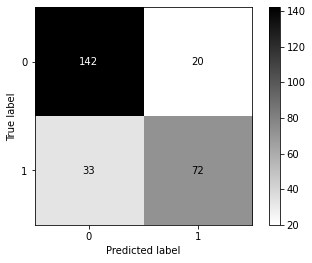

In [25]:
print(confusion_matrix(y_test,y_pred)) #建立confusion matrix
print(lr.score(X_test,y_test))
plot_confusion_matrix(lr,X_test,y_test,cmap='gray_r') #四格都解釋清楚，型一 二 錯誤

In [26]:
a=confusion_matrix(y_test,y_pred)
TN=a[0][0] #TN為左上角，表示預測人死了，且人真的死了
FP=a[0][1] #FP為右上角，表示預測人倖存，但人其實死了。 type 1 error
FN=a[1][0] #FN為左下角，表示預測人死了，且人其實是存活的。 type 2 error
TP=a[1][1] #TP為右下角，表示預測人倖存，且人真的存活。

In [27]:
print(TN,FP,FN,TP)

142 20 33 72


In [28]:
Accuracy=((TP+TN)/(TN+FP+FN+TP)) #accuracy表示所有情況下，預測死亡結果也死亡 預測倖存結果倖存的比例。
recall=TP/(TP+FN) #recall 所有倖存者中，預測倖存中真實倖存的人
precision=TP/(TP+FP) #prescision 表示在預測人存活下，真實存活的數量
f=2*(precision*recall)/(precision+recall) #調和平均

false_Positive_Rate = FP/(FP+TN) #表示在人真實死亡的情況下，以為還活著的人
true_Positive_Rate = TP/(TP+FN) #表示在人真實存活的情況下，倖存者的的比例


In [29]:
print(Accuracy)
print(recall)
print(precision)
print(f)
print(false_Positive_Rate)
print(true_Positive_Rate)

0.8014981273408239
0.6857142857142857
0.782608695652174
0.7309644670050761
0.12345679012345678
0.6857142857142857


In [30]:
#如果是船務公司，肯定不會選擇accuracy,在tn很大的情況下，會造成結果失衡。 我們不需要知道死亡的人的準確度。
#recall is the best decision 保險公司在船難第一時間要知道賠幾個，

----------------------------Homework 5 -----------------------------

In [31]:
from sklearn.tree import DecisionTreeClassifier 
from sklearn.metrics import plot_roc_curve
from sklearn.ensemble import RandomForestClassifier

In [32]:
lr=LogisticRegression() #model load
dt=DecisionTreeClassifier()
rf=RandomForestClassifier()

In [33]:
lr.fit(X_train,y_train);  #model trainning
;
rf.fit(X_train,y_train);

/Users/lilinghung/opt/anaconda3/lib/python3.9/site-packages/sklearn/utils/validation.py:63: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  return f(*args, **kwargs)
/var/folders/ml/hg0w_x455vj5qxkvxjndw2hc0000gn/T/ipykernel_33992/2873332333.py:3: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  rf.fit(X_train,y_train);


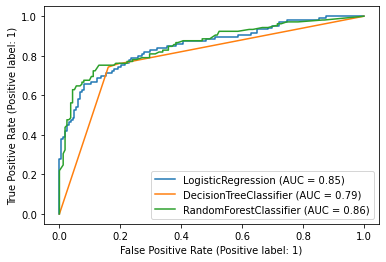

In [34]:
disp=plot_roc_curve(lr,X_test,y_test)            # plot roc curve
plot_roc_curve(dt,X_test,y_test,ax=disp.ax_);    # Random Forest got the best AUC score 0.86
plot_roc_curve(rf,X_test,y_test,ax=disp.ax_);    

In [ ]:
#feature importance

In [61]:
df=pd.read_csv('titanic.csv') #read csv

In [64]:
X=df.iloc[:,:-1] 

y=df['Survived']

In [66]:
X=pd.get_dummies(X,columns=['Sex','Pclass'],drop_first=True) #Pclass Sex get dummies

In [67]:
X

,Age,SiblingsSpouses_Aboard,ParentsChildren_Aboard,Fare,Sex_male,Pclass_2,Pclass_3
0,22.0,1,0,7.2500,1,0,1
1,38.0,1,0,71.2833,0,0,0
2,26.0,0,0,7.9250,0,0,1
3,35.0,1,0,53.1000,0,0,0
4,35.0,0,0,8.0500,1,0,1
...,...,...,...,...,...,...,...
882,27.0,0,0,13.0000,1,1,0
883,19.0,0,0,30.0000,0,0,0
884,7.0,1,2,23.4500,0,0,1
885,26.0,0,0,30.0000,1,0,0


In [68]:
#information gain
from sklearn.feature_selection import mutual_info_classif # 計算entropy

In [69]:
mutual_info = mutual_info_classif(X,y) # model fitting .computing entropy

In [70]:
mutual_data=pd.Series(mutual_info,index=X.columns) #turn entropy into pd series with col names

In [71]:
mutual_data.sort_values(ascending=False)
#sort_values.Ranking all feature importance. Sex is the most importance feature and Fare is the second best.

Sex_male                  0.151655
Fare                      0.130118
Pclass_3                  0.062903
SiblingsSpouses_Aboard    0.034772
ParentsChildren_Aboard    0.030968
Age                       0.027475
Pclass_2                  0.000000
dtype: float64

In [72]:
#extratrees
from sklearn.ensemble import ExtraTreesClassifier
import matplotlib.pyplot as plt
model=ExtraTreesClassifier() #load ExtraTreesClassifier
model.fit(X,y) #model fitting

ExtraTreesClassifier()

In [73]:
ranked_features=pd.Series(model.feature_importances_,index=X.columns) 

<function matplotlib.pyplot.show(close=None, block=None)>

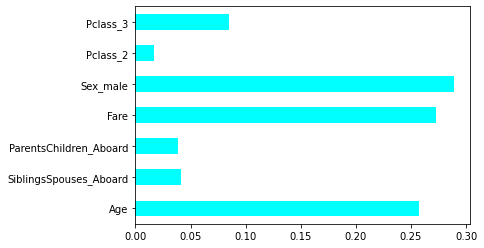

In [74]:
ranked_features.plot(kind='barh',color='aqua')
plt.show #Almost same result as the former mutual info model. but the age feature is much more important

In [75]:
#k best

In [76]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2

In [77]:
rank_feature=SelectKBest(score_func=chi2,k='all') #There are only 7 feautures,so selecting all
order_feature=rank_feature.fit(X,y)  #model fitting

In [78]:
dfscores=pd.DataFrame(order_feature.scores_, columns=['Score']) # create new score df 
dfcols=pd.DataFrame(X.columns)

In [79]:
newdf=pd.concat([dfcols,dfscores],axis=1) # concat score and col_name

In [86]:
newdf.columns=['Features','Score']

In [87]:
newdf

,Features,Score
0,Age,21.343234
1,SiblingsSpouses_Aboard,2.829911
2,ParentsChildren_Aboard,9.668390
3,Fare,4460.558492
4,Sex_male,92.293805
5,Pclass_2,5.913445
6,Pclass_3,40.994193


In [89]:
newdf.nlargest(7,'Score') # the result is different from the above 2 moddel.Fare is the most important feature.

,Features,Score
3,Fare,4460.558492
4,Sex_male,92.293805
6,Pclass_3,40.994193
0,Age,21.343234
2,ParentsChildren_Aboard,9.668390
5,Pclass_2,5.913445
1,SiblingsSpouses_Aboard,2.829911
